In [2]:
import jax 
import jax.numpy as jnp 

from probjax.nn.kernels.attention import mha, BlockSizes
from jax.experimental.pallas.ops.gpu.attention import mha as mha2
from flaxattention.kernel.attention import mha as mha3

In [17]:
#X = jnp.ones((1,2**8, 8,16))
X = jax.random.normal(jax.random.PRNGKey(0), (1,2**18, 8,16))

def causal_mask(b, h, q_idx, kv_idx):
    return q_idx[:, None] >= kv_idx[None, :]

In [16]:
2**18

262144

In [40]:
out = mha(X[:, :64], X[:, :], X[:,:64], None)

In [41]:
out.shape

(1, 64, 8, 16)

In [18]:
out = mha(X, X, X, None, mask_mod=causal_mask).block_until_ready()

In [13]:
%%timeit 

out = mha(X, X, X, None, mask_mod=causal_mask, causal=True).block_until_ready()

Traced<ShapedArray(bool[64,64])>with<DynamicJaxprTrace>
325 μs ± 12.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [5]:
%%timeit
out2 = mha2(X,X,X,None, causal=True).block_until_ready()

299 μs ± 5.81 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [8]:
out = mha(X, X, X, None, mask_mod=causal_mask).block_until_ready()
out2 = mha2(X,X,X,None, causal=True).block_until_ready()
out3 = mha3(X,X,X,None, mask_mod=lambda *args: True, score_mod=lambda *args: args[0]).block_until_ready()
jnp.abs(out - out2).max()

Array(3.631, dtype=float32)

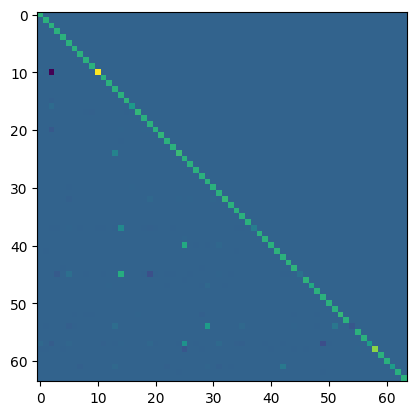

In [17]:
def f1(X):
    return mha2(X, X, X, None, causal=True, block_q=64).sum(axis=(-1,-2))
import matplotlib.pyplot as plt

plt.imshow(jax.jacobian(f1)(X)[0,:,0,:,0,2])

Traced<ShapedArray(bool[64,64])>with<DynamicJaxprTrace>


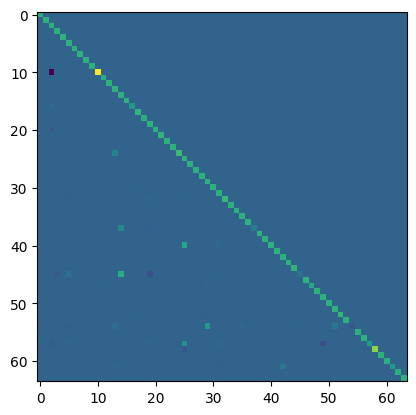

In [16]:

blocks = BlockSizes(64, 64, 64)
def f2(X):
    return mha(X, X, X, None, causal=False, mask_mod=causal_mask).sum(axis=(-1,-2))
import matplotlib.pyplot as plt

plt.imshow(jax.jacobian(f2)(X)[0,:,0,:,0,2])